# How the PSF is applied to the image

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
###############################################################################
# plot_grid() is developed with the assistance of Claude (Anthropic, 2026)
###############################################################################
def plot_grid(arr, cell_size=0.4, out_border_color='black', out_border_size=1, sub=None):
    if sub is None:
        figsize = (arr.shape[1] * cell_size, arr.shape[0] * cell_size)
        _, plot = plt.subplots(figsize=figsize)
    else:
        plot = sub
    plot.imshow(arr, cmap='gray', vmin=0, vmax=1)
    
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color = 'black' if arr[i, j] > 0.5 else 'white'
            plot.text(j, i, arr[i, j], ha='center', va='center', color=color)
            
    for spine in plot.spines.values():
        spine.set_linewidth(out_border_size)
        spine.set_edgecolor(out_border_color)
    
    plot.set_xticks(np.arange(-.5, arr.shape[1], 1), minor=True)
    plot.set_yticks(np.arange(-.5, arr.shape[0], 1), minor=True)
    plot.grid(which='minor', color='gray', linewidth=0.5)
    plot.tick_params(which='minor', length=0)
    plot.set_xticks([])
    plot.set_yticks([])
    
    return plot

In [3]:
def plot_grid_with_title(arr, title, cell_size=0.4, out_border_color='black', out_border_size=1, sub=None):
    plot = plot_grid(arr, cell_size=cell_size, out_border_color=out_border_color, out_border_size=out_border_size, sub=sub)
    plot.set_title(title)


def highlight_cells(plot, row, col, h=1, w=1, color='orange', linewidth=2):
    plot.add_patch(Rectangle((col - 0.5, row - 0.5), w, h,
                             edgecolor=color, facecolor='none', lw=linewidth))

In [4]:
###############################################################################
# plot_conv_step() is developed with the assistance of Claude (Anthropic, 2026)
###############################################################################
def plot_conv_step(psf, img_patch, pos, figsize=(4.5, 2)):
    fig, (plot1, plot2, plot3) = plt.subplots(1, 3, figsize=figsize)
    
    plot_grid_with_title(psf, 'PSF', sub=plot1)
    plot_grid_with_title(img_patch, 'Image Patch', out_border_color='red', out_border_size=2, sub=plot2)
    plot_grid_with_title(np.array([[np.sum(psf * img_patch)]]), f'Output at {pos}', sub=plot3)
    
    fig.text(0.32, 0.5, r'$\odot$', fontsize=30, ha='center', va='center')
    fig.text(0.75, 0.5, r'$\rightarrow \Sigma =$', fontsize=30, ha='center', va='center')
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.6)
    
    highlight_cells(plot2, 1, 1, h=1, w=1, color='orange', linewidth=3)
    pos = plot3.get_position()
    plot3.set_position([pos.x0 + 0.17, pos.y0, pos.width, pos.height])

In [5]:
def plot_conv_step_at_pos(psf, img, pos, psf_pos):
    p_1_1 = plot_grid(img, out_border_size=0)
    highlight_cells(p_1_1, pos[0], pos[1], color='orange', linewidth=3)
    highlight_cells(p_1_1, psf_pos[0], psf_pos[1], h=3, w=3, color='red', linewidth=3)

    heart_1_1 = img[psf_pos[0] : psf_pos[0] + psf.shape[0], psf_pos[1] : psf_pos[1] + psf.shape[1]]
    plot_conv_step(psf, heart_1_1, pos=pos)

## Horizontal PSF step by step

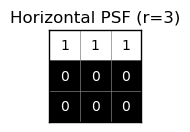

In [6]:
h_psf = np.array([[1,1,1],
                  [0,0,0],
                  [0,0,0]])
plot_grid_with_title(h_psf, 'Horizontal PSF (r=3)')

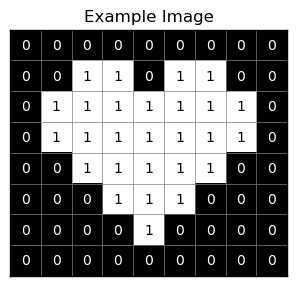

In [7]:
heart = np.array([[0,0,0,0,0,0,0,0,0],
                  [0,0,1,1,0,1,1,0,0],
                  [0,1,1,1,1,1,1,1,0],
                  [0,1,1,1,1,1,1,1,0],
                  [0,0,1,1,1,1,1,0,0],
                  [0,0,0,1,1,1,0,0,0],
                  [0,0,0,0,1,0,0,0,0],
                  [0,0,0,0,0,0,0,0,0]])
plot_grid_with_title(heart, 'Example Image')

### Element-wise multiply and sum
$\left( \text{Image Patch} \right)$ $\odot$ $\left( \text{PSF} \right)$ $\rightarrow \sum$

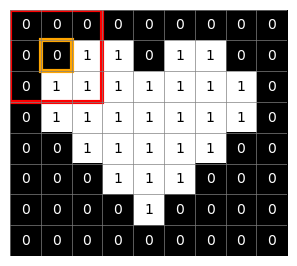

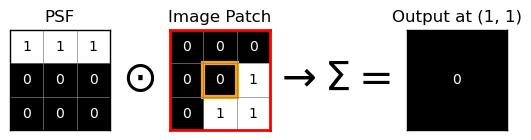

In [8]:
plot_conv_step_at_pos(h_psf, heart, (1,1), (0,0))

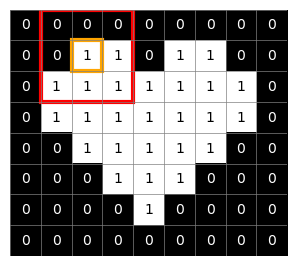

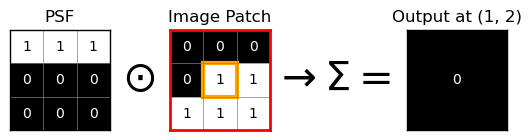

In [9]:
plot_conv_step_at_pos(h_psf, heart, (1,2), (0,1))

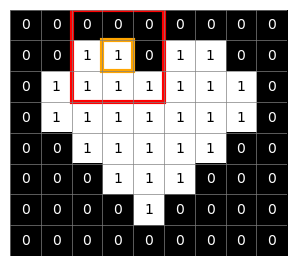

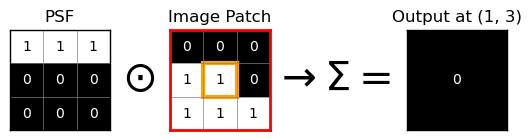

In [10]:
plot_conv_step_at_pos(h_psf, heart, (1,3), (0,2))

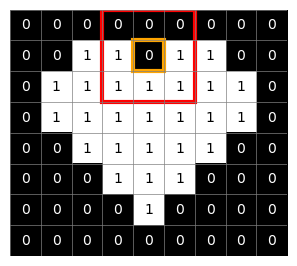

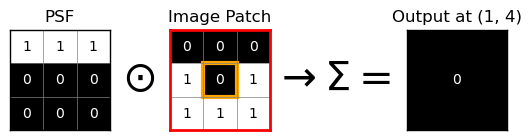

In [11]:
plot_conv_step_at_pos(h_psf, heart, (1,4), (0,3))

----------------
## What about boundaries?

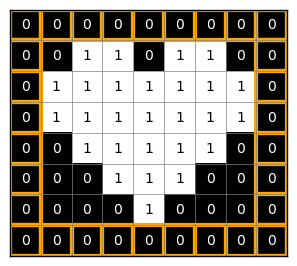

In [12]:
heart_edge = plot_grid(heart)
for j in range(heart.shape[1]):
    highlight_cells(heart_edge, 0, j, color='orange', linewidth=3)
    highlight_cells(heart_edge, heart.shape[0]-1, j, color='orange', linewidth=3)
for i in range(heart.shape[0]):
    highlight_cells(heart_edge, i, 0, color='orange', linewidth=3)
    highlight_cells(heart_edge, i, heart.shape[1]-1, color='orange', linewidth=3)

## Zero Boundary Condition

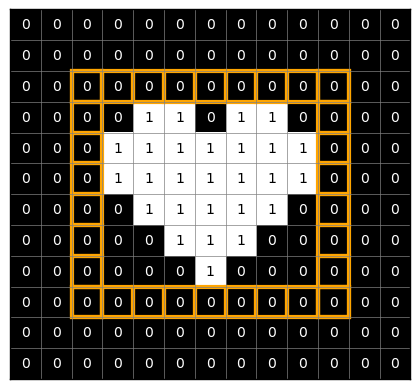

In [13]:
pad_size = 2
heart_zero_padded = np.pad(heart, pad_size, mode="constant", constant_values=0)

heart_edge_zero = plot_grid(heart_zero_padded)
for j in range(pad_size, heart_zero_padded.shape[1]-pad_size):
    highlight_cells(heart_edge_zero, pad_size, j, color='orange', linewidth=3)
    highlight_cells(heart_edge_zero, heart_zero_padded.shape[0]-(pad_size+1), j, color='orange', linewidth=3)
for i in range(pad_size, heart_zero_padded.shape[0]-pad_size):
    highlight_cells(heart_edge_zero, i, pad_size, color='orange', linewidth=3)
    highlight_cells(heart_edge_zero, i, heart_zero_padded.shape[1]-(pad_size+1), color='orange', linewidth=3)

## Periodic Boundary Condition

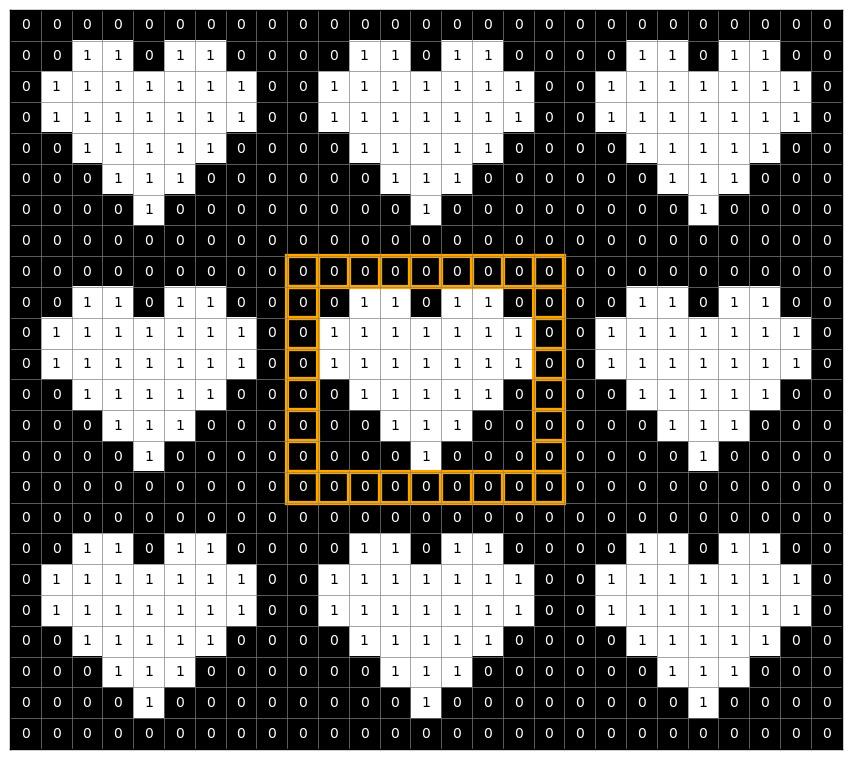

In [14]:
heart_periodic_padded = np.tile(heart, (3, 3))
H, W = heart.shape

heart_edge_periodic = plot_grid(heart_periodic_padded)
for j in range(W, 2*W):
    highlight_cells(heart_edge_periodic, H, j, color='orange', linewidth=3)
    highlight_cells(heart_edge_periodic, 2*H-1, j, color='orange', linewidth=3)
for i in range(H, 2*H):
    highlight_cells(heart_edge_periodic, i, W, color='orange', linewidth=3)
    highlight_cells(heart_edge_periodic, i, 2*W-1, color='orange', linewidth=3)

## Reflexive Boundary Condition

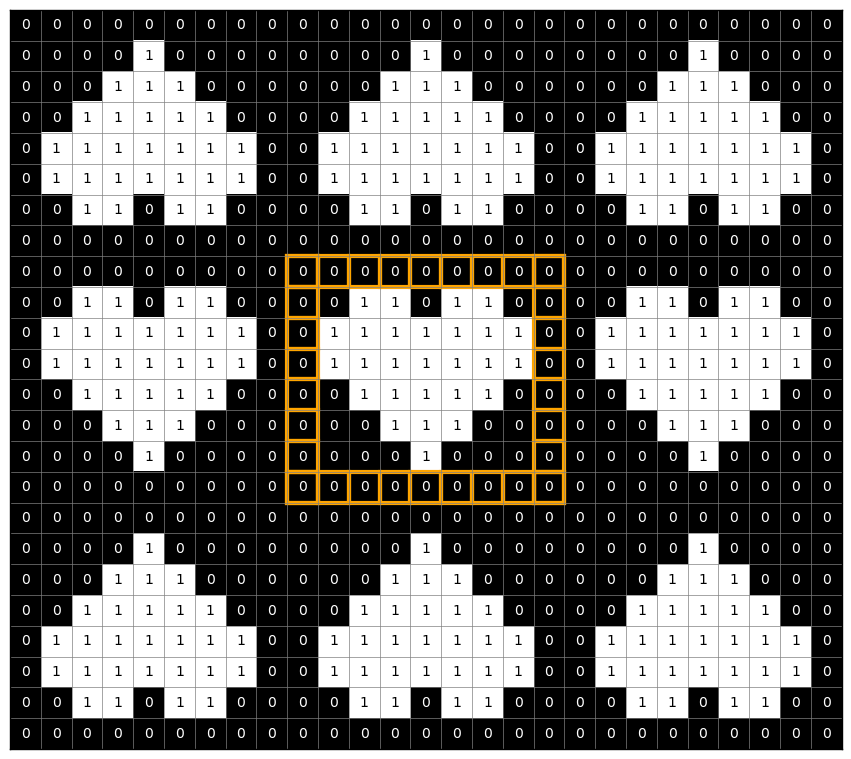

In [15]:
heart_flipud = np.flipud(heart)
heart_fliplr = np.fliplr(heart)
heart_flipboth = np.flipud(np.fliplr(heart))

top = np.hstack([heart_flipboth, heart_flipud, heart_flipboth])
mid = np.hstack([heart_fliplr, heart, heart_fliplr])
bot = np.hstack([heart_flipboth, heart_flipud, heart_flipboth])

heart_reflexive_padded = np.vstack([top, mid, bot])
H, W = heart.shape

heart_edge_reflexive = plot_grid(heart_reflexive_padded)
for j in range(W, 2*W):
    highlight_cells(heart_edge_reflexive, H, j, color='orange', linewidth=3)
    highlight_cells(heart_edge_reflexive, 2*H-1, j, color='orange', linewidth=3)
for i in range(H, 2*H):
    highlight_cells(heart_edge_reflexive, i, W, color='orange', linewidth=3)
    highlight_cells(heart_edge_reflexive, i, 2*W-1, color='orange', linewidth=3)